In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
import os
from glob import glob
import rasterio

In [2]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(torch.cuda.is_available())  # True = CUDA GPU is ready
print(torch.cuda.device_count())  # Number of available GPUs
print(torch.cuda.get_device_name(0))  # Name of first GPU

# Check available CUDA memory
torch.cuda.empty_cache()
free_mem = torch.cuda.mem_get_info()[0] / (1024 ** 3)  # in GB
total_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)  # in GB
print(f"CUDA Free memory: {free_mem:.2f} GB / {total_mem:.2f} GB")

Using device: cuda
True
1
NVIDIA GeForce RTX 3090 Ti
CUDA Free memory: 22.47 GB / 23.99 GB


# Model

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvLSTMUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # ---------- basic blocks ----------
        def double_conv(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        class ConvLSTMCell(nn.Module):
            def __init__(self, in_ch, hid_ch):
                super().__init__()
                self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, 3, padding=1)
                self.hid_ch = hid_ch

            def forward(self, x, h, c):
                combined = torch.cat([x, h], dim=1)
                i, f, o, g = torch.chunk(self.conv(combined), 4, dim=1)
                i = torch.sigmoid(i)
                f = torch.sigmoid(f)
                o = torch.sigmoid(o)
                g = torch.tanh(g)
                c = f * c + i * g
                h = o * torch.tanh(c)
                return h, c

        # ---------- encoder (halved channels) ----------
        self.enc1 = double_conv(1, 16)    # Original: 1→32
        self.enc2 = double_conv(16, 32)   # Original: 32→64
        self.enc3 = double_conv(32, 64)   # Original: 64→128
        self.enc4 = double_conv(64, 128)  # Original: 128→256
        self.pool = nn.MaxPool2d(2)

        # ---------- convlstm (halved channels) ----------
        self.lstm1 = ConvLSTMCell(16, 16)    # Original: 32→32
        self.lstm2 = ConvLSTMCell(32, 32)    # Original: 64→64
        self.lstm3 = ConvLSTMCell(64, 64)    # Original: 128→128
        self.lstm4 = ConvLSTMCell(128, 128)  # Original: 256→256

        # ---------- bottleneck (halved channels) ----------
        self.bottleneck = double_conv(128, 256)  # Original: 256→512

        # ---------- decoder (halved channels) ----------
        self.up4 = nn.ConvTranspose2d(256, 128, 2, stride=2)  # Original: 512→256
        self.dec4 = double_conv(256, 128)  # Original: 512→256

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)  # Original: 256→128
        self.dec3 = double_conv(128, 64)   # Original: 256→128

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)  # Original: 128→64
        self.dec2 = double_conv(64, 32)    # Original: 128→64

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)  # Original: 64→32
        self.dec1 = double_conv(32, 16)    # Original: 64→32
        
        # ---------- output ----------
        self.final = nn.Conv2d(16, 1, 1)  # Original: 32→1

    def _align(self, src, tgt):
        """Helper function to align feature map sizes"""
        if src.shape[2:] != tgt.shape[2:]:
            src = F.interpolate(src, size=tgt.shape[2:], mode="bilinear", align_corners=False)
        return src

    def forward(self, x):
        B, T, H, W = x.shape
        device = x.device

        # Initialize hidden states for ConvLSTM cells
        h1 = c1 = torch.zeros(B, 16, H, W, device=device)
        h2 = c2 = torch.zeros(B, 32, H//2, W//2, device=device)
        h3 = c3 = torch.zeros(B, 64, H//4, W//4, device=device)
        h4 = c4 = torch.zeros(B, 128, H//8, W//8, device=device)

        # Process each timestep
        for t in range(T):
            xt = x[:, t].unsqueeze(1)

            # Encoder path with ConvLSTM
            e1 = self.enc1(xt)
            h1, c1 = self.lstm1(e1, h1, c1)
            p1 = self.pool(h1)

            e2 = self.enc2(p1)
            h2, c2 = self.lstm2(e2, h2, c2)
            p2 = self.pool(h2)

            e3 = self.enc3(p2)
            h3, c3 = self.lstm3(e3, h3, c3)
            p3 = self.pool(h3)

            e4 = self.enc4(p3)
            h4, c4 = self.lstm4(e4, h4, c4)

        # Bottleneck
        btm = self.bottleneck(h4)

        # Decoder path with skip connections
        u4 = self._align(self.up4(btm), h4)
        d4 = self.dec4(torch.cat([u4, h4], dim=1))

        u3 = self._align(self.up3(d4), h3)
        d3 = self.dec3(torch.cat([u3, h3], dim=1))

        u2 = self._align(self.up2(d3), h2)
        d2 = self.dec2(torch.cat([u2, h2], dim=1))

        u1 = self._align(self.up1(d2), h1)
        d1 = self.dec1(torch.cat([u1, h1], dim=1))

        # Final output
        output = self.final(d1)
        return torch.sigmoid(output)
    
# Test the model
model = ConvLSTMUNet()
# print model parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total model parameters: {total_params}")
print(model)

Total model parameters: 3511441
ConvLSTMUNet(
  (enc1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, mo

# DATASET FOR BINARY MASKS

In [4]:
# Path to your folder (update this path to match your local system)
folder_path = r"D:\RUbel Ahmmed 0421162025\Data\Harirampur Padma\ALL Water Polygon"
# Get all .tif files in the folder
LS_NIR = sorted(glob(os.path.join(folder_path, '*.tif')))
print(f"Found {len(LS_NIR)} GeoTIFF images.")
# # Check the number of bands for each .tif file
# for tif in LS_NIR:
#     with rasterio.open(tif) as src:
#         print(f"{os.path.basename(tif)} - Number of bands: {src.count}")
#         print(f"Width: {src.width}, Height: {src.height}")
# # =================== Visualization of first 38 images ===================
# plt.figure(figsize=(30, 20))
# for i, tif in enumerate(LS_NIR[:38]):  # Display first 6 images
#     with rasterio.open(tif) as src:
#         band1 = src.read(1)
#     plt.subplot(5, 8, i+1)
#     plt.imshow(band1, cmap='gray')
#     # Display split upto  2nd _ filename as title
#     plt.title(os.path.basename(tif).split('_')[0:2])
#     plt.axis('off')
# plt.tight_layout()
# plt.show()

# =================== Load images into a time-series array ===================
LS_NIR_List = []
crs = None
transform = None
for i, tif in enumerate(LS_NIR):
    with rasterio.open(tif) as src:
        img = src.read(1).astype(np.float32)  # Read all 3 bands
        # img = np.moveaxis(img, 0, -1)  # Reorder the dimensions (from [bands, height, width] to [height, width, bands])
        LS_NIR_List.append(img)
        if i == 0:
            crs = src.crs
            transform = src.transform
# Stack into time-series array: shape [time, height, width, bands]
LS_NIR_Seq = np.stack(LS_NIR_List).astype(np.float32)
print("Image sequence shape:", LS_NIR_Seq.shape)
print("CRS:", crs)
print("Transform:", transform)

data = torch.tensor(LS_NIR_Seq)  # [time, channels, height, width]
print("Data tensor shape:", data.shape)

def create_dataset(data, input_seq_len, target_seq_len):
    inputs = []
    targets = []
    total_seq_len = input_seq_len + target_seq_len
    for i in range(len(data) - total_seq_len + 1):
        input_seq = data[i:i+input_seq_len]
        target_seq = data[i+input_seq_len:i+total_seq_len]
        inputs.append(input_seq)
        targets.append(target_seq)
    return torch.stack(inputs), torch.stack(targets)

input_seq_len = 5
target_seq_len = 1
inputs, targets = create_dataset(data, input_seq_len, target_seq_len)
inputs = inputs  # Add channel dimension
print("Inputs shape:", inputs.shape)
print("Targets shape:", targets.shape)

x_train = inputs[:32]
y_train = targets[:32]
x_val = inputs[32:]
y_val = targets[32:]
x_test = inputs[32:]
y_test = targets[32:]
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# ==================== Create DataLoader ====================
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)

# CHeck DataLoader
for x_train, y_train in train_loader:
    pred_batch = model(x_train)
    print("x_train Shape :", x_train.shape)
    print("Predicted Shape :", pred_batch.shape)
    print("Actual y_train Shape :", y_train.shape)
    break

Found 38 GeoTIFF images.
Image sequence shape: (38, 755, 945)
CRS: EPSG:32645
Transform: | 30.00, 0.00, 785220.00|
| 0.00,-30.00, 2630850.00|
| 0.00, 0.00, 1.00|
Data tensor shape: torch.Size([38, 755, 945])
Inputs shape: torch.Size([33, 5, 755, 945])
Targets shape: torch.Size([33, 1, 755, 945])
x_train shape: torch.Size([32, 5, 755, 945])
y_train shape: torch.Size([32, 1, 755, 945])
x_val shape: torch.Size([1, 5, 755, 945])
y_val shape: torch.Size([1, 1, 755, 945])
x_test shape: torch.Size([1, 5, 755, 945])
y_test shape: torch.Size([1, 1, 755, 945])
x_train Shape : torch.Size([4, 5, 755, 945])
Predicted Shape : torch.Size([4, 1, 755, 945])
Actual y_train Shape : torch.Size([4, 1, 755, 945])


# LOSS FUNCTIONS

In [5]:
# ==================== LOSS FUNCTIONS ====================
class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=1.0, dice_weight=1.0, iou_weight=1.0, pos_weight=2.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.iou_weight = iou_weight
        self.pos_weight = pos_weight
        
    def bce_loss(self, predictions, targets):
        bce = F.binary_cross_entropy_with_logits(
            predictions, targets, reduction='none', pos_weight=torch.tensor(self.pos_weight)
        )
        return bce.mean()
    
    def dice_loss(self, predictions, targets, smooth=1e-6):
        # Apply sigmoid to predictions
        predictions = torch.sigmoid(predictions)
        
        # Flatten predictions and targets
        predictions_flat = predictions.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (predictions_flat * targets_flat).sum()
        dice = (2. * intersection + smooth) / (predictions_flat.sum() + targets_flat.sum() + smooth)
        
        return 1 - dice
    
    def iou_loss(self, predictions, targets, smooth=1e-6):
        # Apply sigmoid to predictions
        predictions = torch.sigmoid(predictions)
        
        # Flatten predictions and targets
        predictions_flat = predictions.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (predictions_flat * targets_flat).sum()
        union = predictions_flat.sum() + targets_flat.sum() - intersection
        
        iou = (intersection + smooth) / (union + smooth)
        
        return 1 - iou
    
    def forward(self, predictions, targets):
        # Calculate individual losses
        bce_loss = self.bce_loss(predictions, targets)
        dice_loss = self.dice_loss(predictions, targets)
        iou_loss = self.iou_loss(predictions, targets)
        
        # Combine losses with weights
        total_loss = (
            self.bce_weight * bce_loss + 
            self.dice_weight * dice_loss + 
            self.iou_weight * iou_loss
        )
        
        # Return total loss and individual losses for logging
        loss_dict = {
            'total_loss': total_loss.item(),
            'bce_loss': bce_loss.item(),
            'dice_loss': dice_loss.item(),
            'iou_loss': iou_loss.item()
        }
        
        return total_loss, loss_dict
    
# Sample usage:
criterion = CombinedLoss(bce_weight=1.0, dice_weight=1.0, iou_weight=1.0, pos_weight=2.0)

for x_batch, y_batch in train_loader:
    y_pred = model(x_batch)
    loss, loss_details = criterion(y_pred, y_batch)
    print("Training Loss:", loss.item())
    print("Loss Details:", loss_details)
    break  


Training Loss: 2.4840238094329834
Loss Details: {'total_loss': 2.4840238094329834, 'bce_loss': 0.9714977741241455, 'dice_loss': 0.6935071349143982, 'iou_loss': 0.8190188407897949}


# TRAINING Loops

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np

# ==================== TRAINING SETUP ====================
# Save directory
save_dir = r"D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_04_Unet"  
os.makedirs(save_dir, exist_ok=True) 

# Additional save paths
checkpoint_dir = os.path.join(save_dir, "checkpoints")
logs_dir = os.path.join(save_dir, "logs")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)

# Training parameters
num_epochs = 200
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Loss weights (you can adjust these)
bce_weight = 1.0
dice_weight = 1.0
iou_weight = 0.5
pos_weight = 2.0

# Create model and move to device
model = ConvLSTMUNet().to(device)

# Initialize loss function
criterion = CombinedLoss(
    bce_weight=bce_weight, 
    dice_weight=dice_weight, 
    iou_weight=iou_weight, 
    pos_weight=pos_weight
)

# Initialize optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping parameters
patience = 30
min_delta = 1e-4
best_val_loss = float('inf')
patience_counter = 0

# Model paths
best_model_path = os.path.join(checkpoint_dir, "best_model_combined_loss.pth")
last_model_path = os.path.join(checkpoint_dir, "last_model_combined_loss.pth")

# Logging lists
train_losses = []
val_losses = []

# ==================== TRAINING LOOP (SIMPLIFIED) ====================
print(f"Starting training for {num_epochs} epochs with combined loss...")
print(f"Model: {model.__class__.__name__}")
print(f"Optimizer: Adam (lr={learning_rate}, weight_decay=1e-5)")
print(f"Loss weights - BCE: {bce_weight}, Dice: {dice_weight}, IoU: {iou_weight}")
print(f"Positive weight for BCE: {pos_weight}")
print(f"Device: {device}")
print(f"Batch size: 4")
print("-" * 80)

for epoch in range(num_epochs):
    # ========== Training Phase ==========
    model.train()
    train_total_loss = 0.0
    train_bce_loss = 0.0
    train_dice_loss = 0.0
    train_iou_loss = 0.0
    
    # Track batch progress
    total_batches = len(train_loader)
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(inputs)
        
        # Calculate combined loss
        total_loss, loss_dict = criterion(predictions, targets)
        
        # Backward pass
        total_loss.backward()
        
        # Gradient clipping to prevent explosions
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Accumulate losses
        train_total_loss += loss_dict['total_loss']
        train_bce_loss += loss_dict['bce_loss']
        train_dice_loss += loss_dict['dice_loss']
        train_iou_loss += loss_dict['iou_loss']
        
        # Print batch progress (simplified)
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Batch [{batch_idx+1}/{total_batches}], '
              f'Loss: {loss_dict["total_loss"]:.4f}')

    # Calculate average training losses
    avg_train_total = train_total_loss / total_batches
    avg_train_bce = train_bce_loss / total_batches
    avg_train_dice = train_dice_loss / total_batches
    avg_train_iou = train_iou_loss / total_batches
    
    train_losses.append(avg_train_total)

    # ========== Validation Phase ==========
    model.eval()
    val_total_loss = 0.0
    val_bce_loss = 0.0
    val_dice_loss = 0.0
    val_iou_loss = 0.0
    
    with torch.no_grad():
        val_batches = len(test_loader)
        
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            predictions = model(inputs)
            
            # Calculate combined loss
            total_loss, loss_dict = criterion(predictions, targets)
            
            # Accumulate losses
            val_total_loss += loss_dict['total_loss']
            val_bce_loss += loss_dict['bce_loss']
            val_dice_loss += loss_dict['dice_loss']
            val_iou_loss += loss_dict['iou_loss']
            
            # Print validation batch progress (optional)
            if batch_idx == 0:  # Just print first batch to reduce clutter
                print(f'Val Batch [{batch_idx+1}/{val_batches}], Loss: {loss_dict["total_loss"]:.4f}')

    # Calculate average validation losses
    avg_val_total = val_total_loss / val_batches
    avg_val_bce = val_bce_loss / val_batches
    avg_val_dice = val_dice_loss / val_batches
    avg_val_iou = val_iou_loss / val_batches
    
    val_losses.append(avg_val_total)
    
    # Update learning rate scheduler
    scheduler.step(avg_val_total)

    # ========== Early Stopping Check ==========
    if avg_val_total < best_val_loss - min_delta:
        best_val_loss = avg_val_total
        patience_counter = 0
    else:
        patience_counter += 1
    
    # ========== Checkpointing ==========
    # Save best model
    if avg_val_total == best_val_loss:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': best_val_loss,
            'train_loss': avg_train_total,
            'loss_weights': {'bce': bce_weight, 'dice': dice_weight, 'iou': iou_weight},
            'pos_weight': pos_weight
        }, best_model_path)
        print(f"✓ New best model saved! Val Loss: {best_val_loss:.4f}")

    # Save last model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_loss': avg_val_total,
        'train_loss': avg_train_total,
    }, last_model_path)

    # Save periodic checkpoints
    if (epoch + 1) % 10 == 0:
        periodic_path = os.path.join(checkpoint_dir, f"model_epoch_{epoch+1}_combined.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': avg_val_total,
            'train_loss': avg_train_total,
        }, periodic_path)
        print(f"✓ Periodic checkpoint saved at epoch {epoch+1}")

    # ========== Epoch Summary ==========
    print(f'\n{"="*60}')
    print(f'Epoch {epoch+1}/{num_epochs} Summary:')
    print(f'{"-"*40}')
    print(f'Train Loss: {avg_train_total:.4f} (BCE: {avg_train_bce:.4f}, Dice: {avg_train_dice:.4f}, IoU: {avg_train_iou:.4f})')
    print(f'Val Loss:   {avg_val_total:.4f} (BCE: {avg_val_bce:.4f}, Dice: {avg_val_dice:.4f}, IoU: {avg_val_iou:.4f})')
    print(f'{"-"*40}')
    print(f'Best Val Loss: {best_val_loss:.4f}')
    print(f'Current LR: {optimizer.param_groups[0]["lr"]:.6f}')
    print(f'Early stopping patience: {patience_counter}/{patience}')
    print(f'{"="*60}\n')
    
    # Check for early stopping
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print("Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

# ==================== SAVE TRAINING HISTORY ====================
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
    'num_epochs_trained': epoch + 1,
    'loss_weights': {'bce': bce_weight, 'dice': dice_weight, 'iou': iou_weight},
    'pos_weight': pos_weight
}

history_path = os.path.join(save_dir, "training_history_simple.npy")
np.save(history_path, history, allow_pickle=True)
print(f"Training history saved to {history_path}")

Using device: cuda
Starting training for 200 epochs with combined loss...
Model: ConvLSTMUNet
Optimizer: Adam (lr=0.001, weight_decay=1e-5)
Loss weights - BCE: 1.0, Dice: 1.0, IoU: 0.5
Positive weight for BCE: 2.0
Device: cuda
Batch size: 4
--------------------------------------------------------------------------------
Epoch [1/200], Batch [1/8], Loss: 2.0650
Epoch [1/200], Batch [2/8], Loss: 1.9894
Epoch [1/200], Batch [3/8], Loss: 1.9581
Epoch [1/200], Batch [4/8], Loss: 1.9416
Epoch [1/200], Batch [5/8], Loss: 1.9143
Epoch [1/200], Batch [6/8], Loss: 1.9068
Epoch [1/200], Batch [7/8], Loss: 1.8996
Epoch [1/200], Batch [8/8], Loss: 1.8766
Val Batch [1/1], Loss: 2.0148
✓ New best model saved! Val Loss: 2.0148

Epoch 1/200 Summary:
----------------------------------------
Train Loss: 1.9439 (BCE: 0.8986, Dice: 0.6510, IoU: 0.7885)
Val Loss:   2.0148 (BCE: 0.9230, Dice: 0.6852, IoU: 0.8132)
----------------------------------------
Best Val Loss: 2.0148
Current LR: 0.001000
Early stoppi

# Evaluate and Plot

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def evaluate_model(model, test_loader, device='cpu'):
    """Comprehensive evaluation of river prediction model"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float()
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    return all_preds, all_targets

def calculate_river_metrics(y_true, y_pred):
    """Calculate river-specific metrics"""
    y_true_np = y_true.cpu().numpy().flatten()
    y_pred_np = y_pred.cpu().numpy().flatten()
    
    # Basic classification metrics
    cm = confusion_matrix(y_true_np, y_pred_np)
    tn, fp, fn, tp = cm.ravel()
    
    # River-specific metrics
    total_pixels = y_true_np.size
    water_pixels_true = np.sum(y_true_np == 1)
    water_pixels_pred = np.sum(y_pred_np == 1)
    
    # Hydrological metrics
    iou_water = tp / (tp + fp + fn + 1e-10)
    iou_land = tn / (tn + fp + fn + 1e-10)
    
    # Connectivity metrics (approximate)
    from scipy import ndimage
    pred_water = y_pred[0, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    true_water = y_true[0, 0].cpu().numpy() if y_true.dim() > 2 else y_true.cpu().numpy()
    
    # Number of connected water bodies
    labeled_pred, num_features_pred = ndimage.label(pred_water > 0.5)
    labeled_true, num_features_true = ndimage.label(true_water > 0.5)
    
    metrics = {
        'accuracy': (tp + tn) / (tp + tn + fp + fn),
        'precision_water': tp / (tp + fp + 1e-10),
        'recall_water': tp / (tp + fn + 1e-10),
        'f1_water': 2 * tp / (2 * tp + fp + fn + 1e-10),
        'iou_water': iou_water,
        'iou_land': iou_land,
        'water_pixels_true': water_pixels_true,
        'water_pixels_pred': water_pixels_pred,
        'water_area_ratio_true': water_pixels_true / total_pixels,
        'water_area_ratio_pred': water_pixels_pred / total_pixels,
        'num_water_bodies_true': num_features_true,
        'num_water_bodies_pred': num_features_pred,
        'false_positive_rate': fp / (fp + tn + 1e-10),
        'false_negative_rate': fn / (fn + tp + 1e-10),
    }
    
    return metrics, cm



def generate_detailed_report(metrics, model_name="Conv3D River Predictor"):
    """Generate detailed evaluation report"""
    report = f"""
    {'='*60}
    RIVER PLANFORM PREDICTION EVALUATION REPORT
    {'='*60}
    Model: {model_name}
    Timestamp: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
    
    {'-'*60}
    CLASSIFICATION METRICS:
    {'-'*60}
    Accuracy:           {metrics['accuracy']:.4f}
    Precision (Water):  {metrics['precision_water']:.4f}
    Recall (Water):     {metrics['recall_water']:.4f}
    F1-Score (Water):   {metrics['f1_water']:.4f}
    
    {'-'*60}
    SEGMENTATION METRICS:
    {'-'*60}
    IoU (Water):        {metrics['iou_water']:.4f}
    IoU (Land):         {metrics['iou_land']:.4f}
    False Positive Rate: {metrics['false_positive_rate']:.4f}
    False Negative Rate: {metrics['false_negative_rate']:.4f}
    
    {'-'*60}
    RIVER MORPHOLOGY:
    {'-'*60}
    Water Pixels (True):  {metrics['water_pixels_true']:,}
    Water Pixels (Pred):  {metrics['water_pixels_pred']:,}
    Water Area Ratio:     {metrics['water_area_ratio_true']:.4f}
    Water Bodies (True):  {metrics['num_water_bodies_true']}
    Water Bodies (Pred):  {metrics['num_water_bodies_pred']}
    
    {'='*60}
    """
    print(report)
    
    # Return as dictionary for further analysis
    return metrics

# ====== MAIN EVALUATION PIPELINE ======
if __name__ == "__main__":
    # Load your trained model
    model = ConvLSTMUNet()  # Your model class
    # CORRECT WAY:
    checkpoint = torch.load(r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_04_Unet\checkpoints\best_model_combined_loss.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # 1. Evaluate on test data
    print("Evaluating model on test data...")
    y_pred, y_true = evaluate_model(model, test_loader, device)
    
    # 2. Calculate metrics
    metrics, cm = calculate_river_metrics(y_true, y_pred)
    
    # 3. Generate report
    generate_detailed_report(metrics)
    
    

Evaluating model on test data...

    RIVER PLANFORM PREDICTION EVALUATION REPORT
    Model: Conv3D River Predictor
    Timestamp: 2026-01-30 14:18:52

    ------------------------------------------------------------
    CLASSIFICATION METRICS:
    ------------------------------------------------------------
    Accuracy:           0.9388
    Precision (Water):  0.7952
    Recall (Water):     0.9363
    F1-Score (Water):   0.8600

    ------------------------------------------------------------
    SEGMENTATION METRICS:
    ------------------------------------------------------------
    IoU (Water):        0.7544
    IoU (Land):         0.9247
    False Positive Rate: 0.0605
    False Negative Rate: 0.0637

    ------------------------------------------------------------
    RIVER MORPHOLOGY:
    ------------------------------------------------------------
    Water Pixels (True):  143,162
    Water Pixels (Pred):  168,562
    Water Area Ratio:     0.2007
    Water Bodies (True):  125

# Traing History Plot

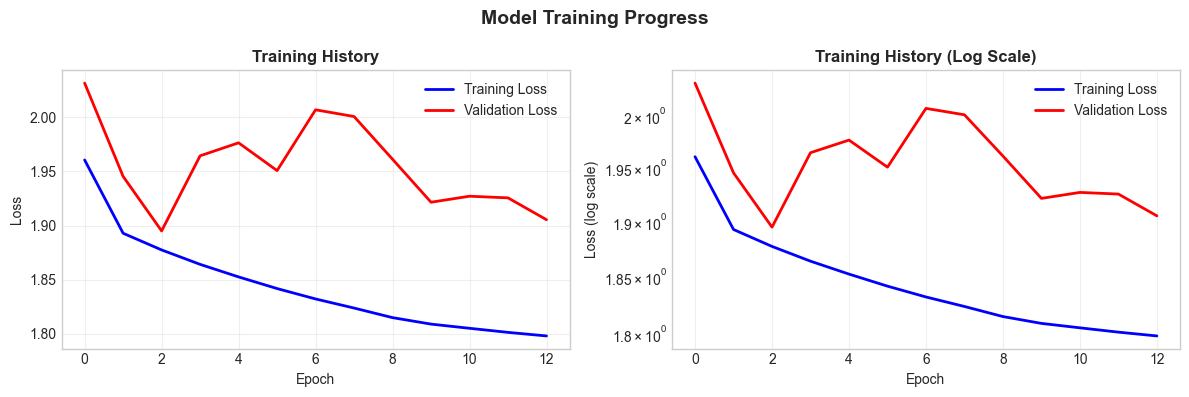

In [10]:
def plot_training_history(loss_history, val_loss_history, save_path=None):
    """Plot training and validation loss history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curves
    ax1.plot(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax1.plot(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training History', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Log scale for better visualization
    ax2.semilogy(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax2.semilogy(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss (log scale)')
    ax2.set_title('Training History (Log Scale)', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Load the training history
train_history_path = r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_04_Unet\training_history_simple.npy'
history = np.load(train_history_path, allow_pickle=True).item()
# print("Keys in history:", history.keys())
# Keys in history: dict_keys(['train_losses', 'val_losses', 'best_val_loss', 'num_epochs_trained', 'loss_weights', 'pos_weight'])
train_losses = history['train_losses']
val_losses = history['val_losses']
# Plot training history
plot_training_history(train_losses, val_losses, save_path=None)

# Actual vs Prediction Plot

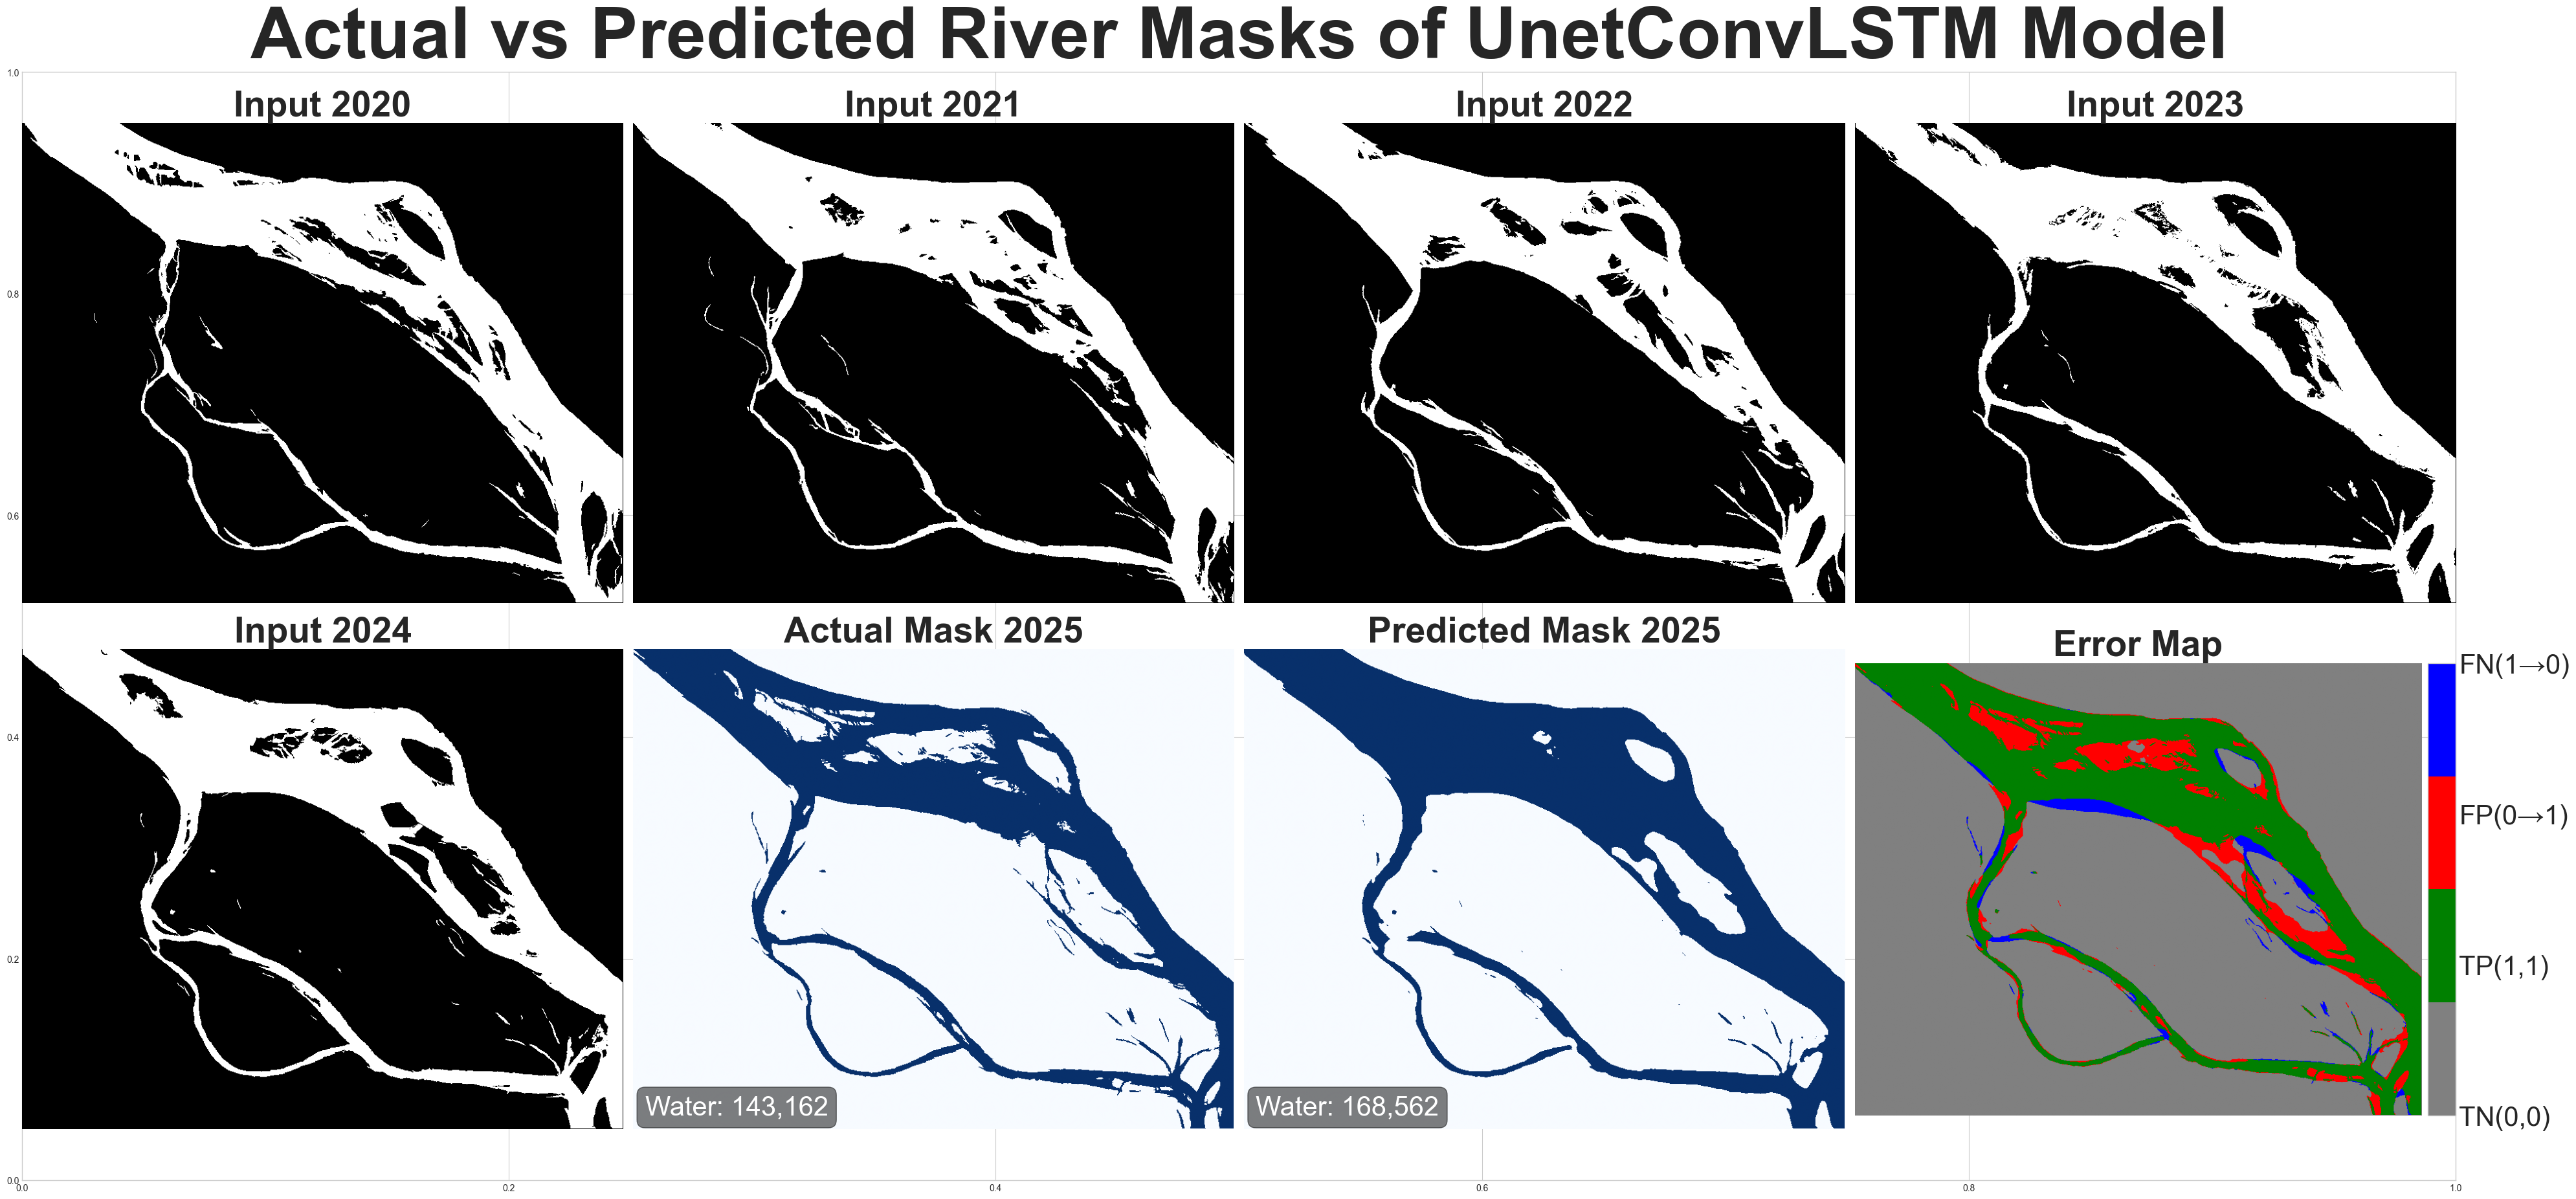

In [12]:
def visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None):
    """Enhanced visualization with metrics - assuming x_test has shape [batch, seq_len, 1, H, W]"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(x_test, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    x_test_bin = x_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Classification map
    result = torch.zeros_like(y_test_bin, dtype=torch.int8)
    result[(y_test_bin == 1) & (y_pred_bin == 1)] = 1     # True Positive
    result[(y_test_bin == 0) & (y_pred_bin == 1)] = 2     # False Positive
    result[(y_test_bin == 1) & (y_pred_bin == 0)] = 3     # False Negative
    
    # Colors and labels
    cmap = ListedColormap(['gray', 'green', 'red', 'blue'])
    labels = ['TN(0,0)', 'TP(1,1)', 'FP(0→1)', 'FN(1→0)']
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Create figure with 2×4 grid
    fig = plt.figure(figsize=(40, 20))
    
    # Assuming x_test shape: [batch, sequence_len=5, 1, H, W]
    time_labels = ['2020', '2021', '2022', '2023', '2024']
    plt.title('Actual vs Predicted River Masks of UnetConvLSTM Model', fontsize=80, fontweight='bold')
    # Plot all 5 input frames (columns 1-5)
    for i in range(5):
        ax = plt.subplot(2, 4, i+1)
        
        # Get the i-th frame in the sequence
        if x_test.dim() == 5:  # [batch, seq_len, channels, H, W]
            img_to_show = x_test[sample_idx, i, 0].cpu().numpy()
        elif x_test.dim() == 4:  # [batch, seq_len*channels, H, W]
            img_to_show = x_test[sample_idx, i].cpu().numpy()
        else:
            img_to_show = x_test[sample_idx].cpu().numpy()
        
        ax.imshow(img_to_show, cmap='gray')
        ax.set_title(f'Input {time_labels[i]}', fontsize=40, fontweight='bold')
        ax.axis('off')
    
    # 6: Actual River Mask (t)
    ax6 = plt.subplot(2, 4, 6)
    actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.dim() > 2 else y_test.cpu().numpy()
    ax6.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
    ax6.set_title('Actual Mask 2025', fontsize=40, fontweight='bold')
    ax6.axis('off')
    ax6.text(0.02, 0.02, f'Water: {metrics["water_pixels_true"]:,}', 
             transform=ax6.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 7: Predicted River Mask (t)
    ax7 = plt.subplot(2, 4, 7)
    pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    ax7.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
    ax7.set_title('Predicted Mask 2025', fontsize=40, fontweight='bold')
    ax7.axis('off')
    ax7.text(0.02, 0.02, f'Water: {metrics["water_pixels_pred"]:,}', 
             transform=ax7.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 8: Error Classification
    ax8 = plt.subplot(2, 4, 8)
    error_map = result[sample_idx, 0].cpu().numpy() if result.dim() > 2 else result.cpu().numpy()
    im = ax8.imshow(error_map, cmap=cmap, vmin=0, vmax=3)
    ax8.set_title('Error Map', fontsize=40, fontweight='bold')
    ax8.axis('off')
    
    # Add colorbar for error map
    divider = make_axes_locatable(ax8)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(labels, fontsize=30)
   
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None)

# Evaluation Matrix plot

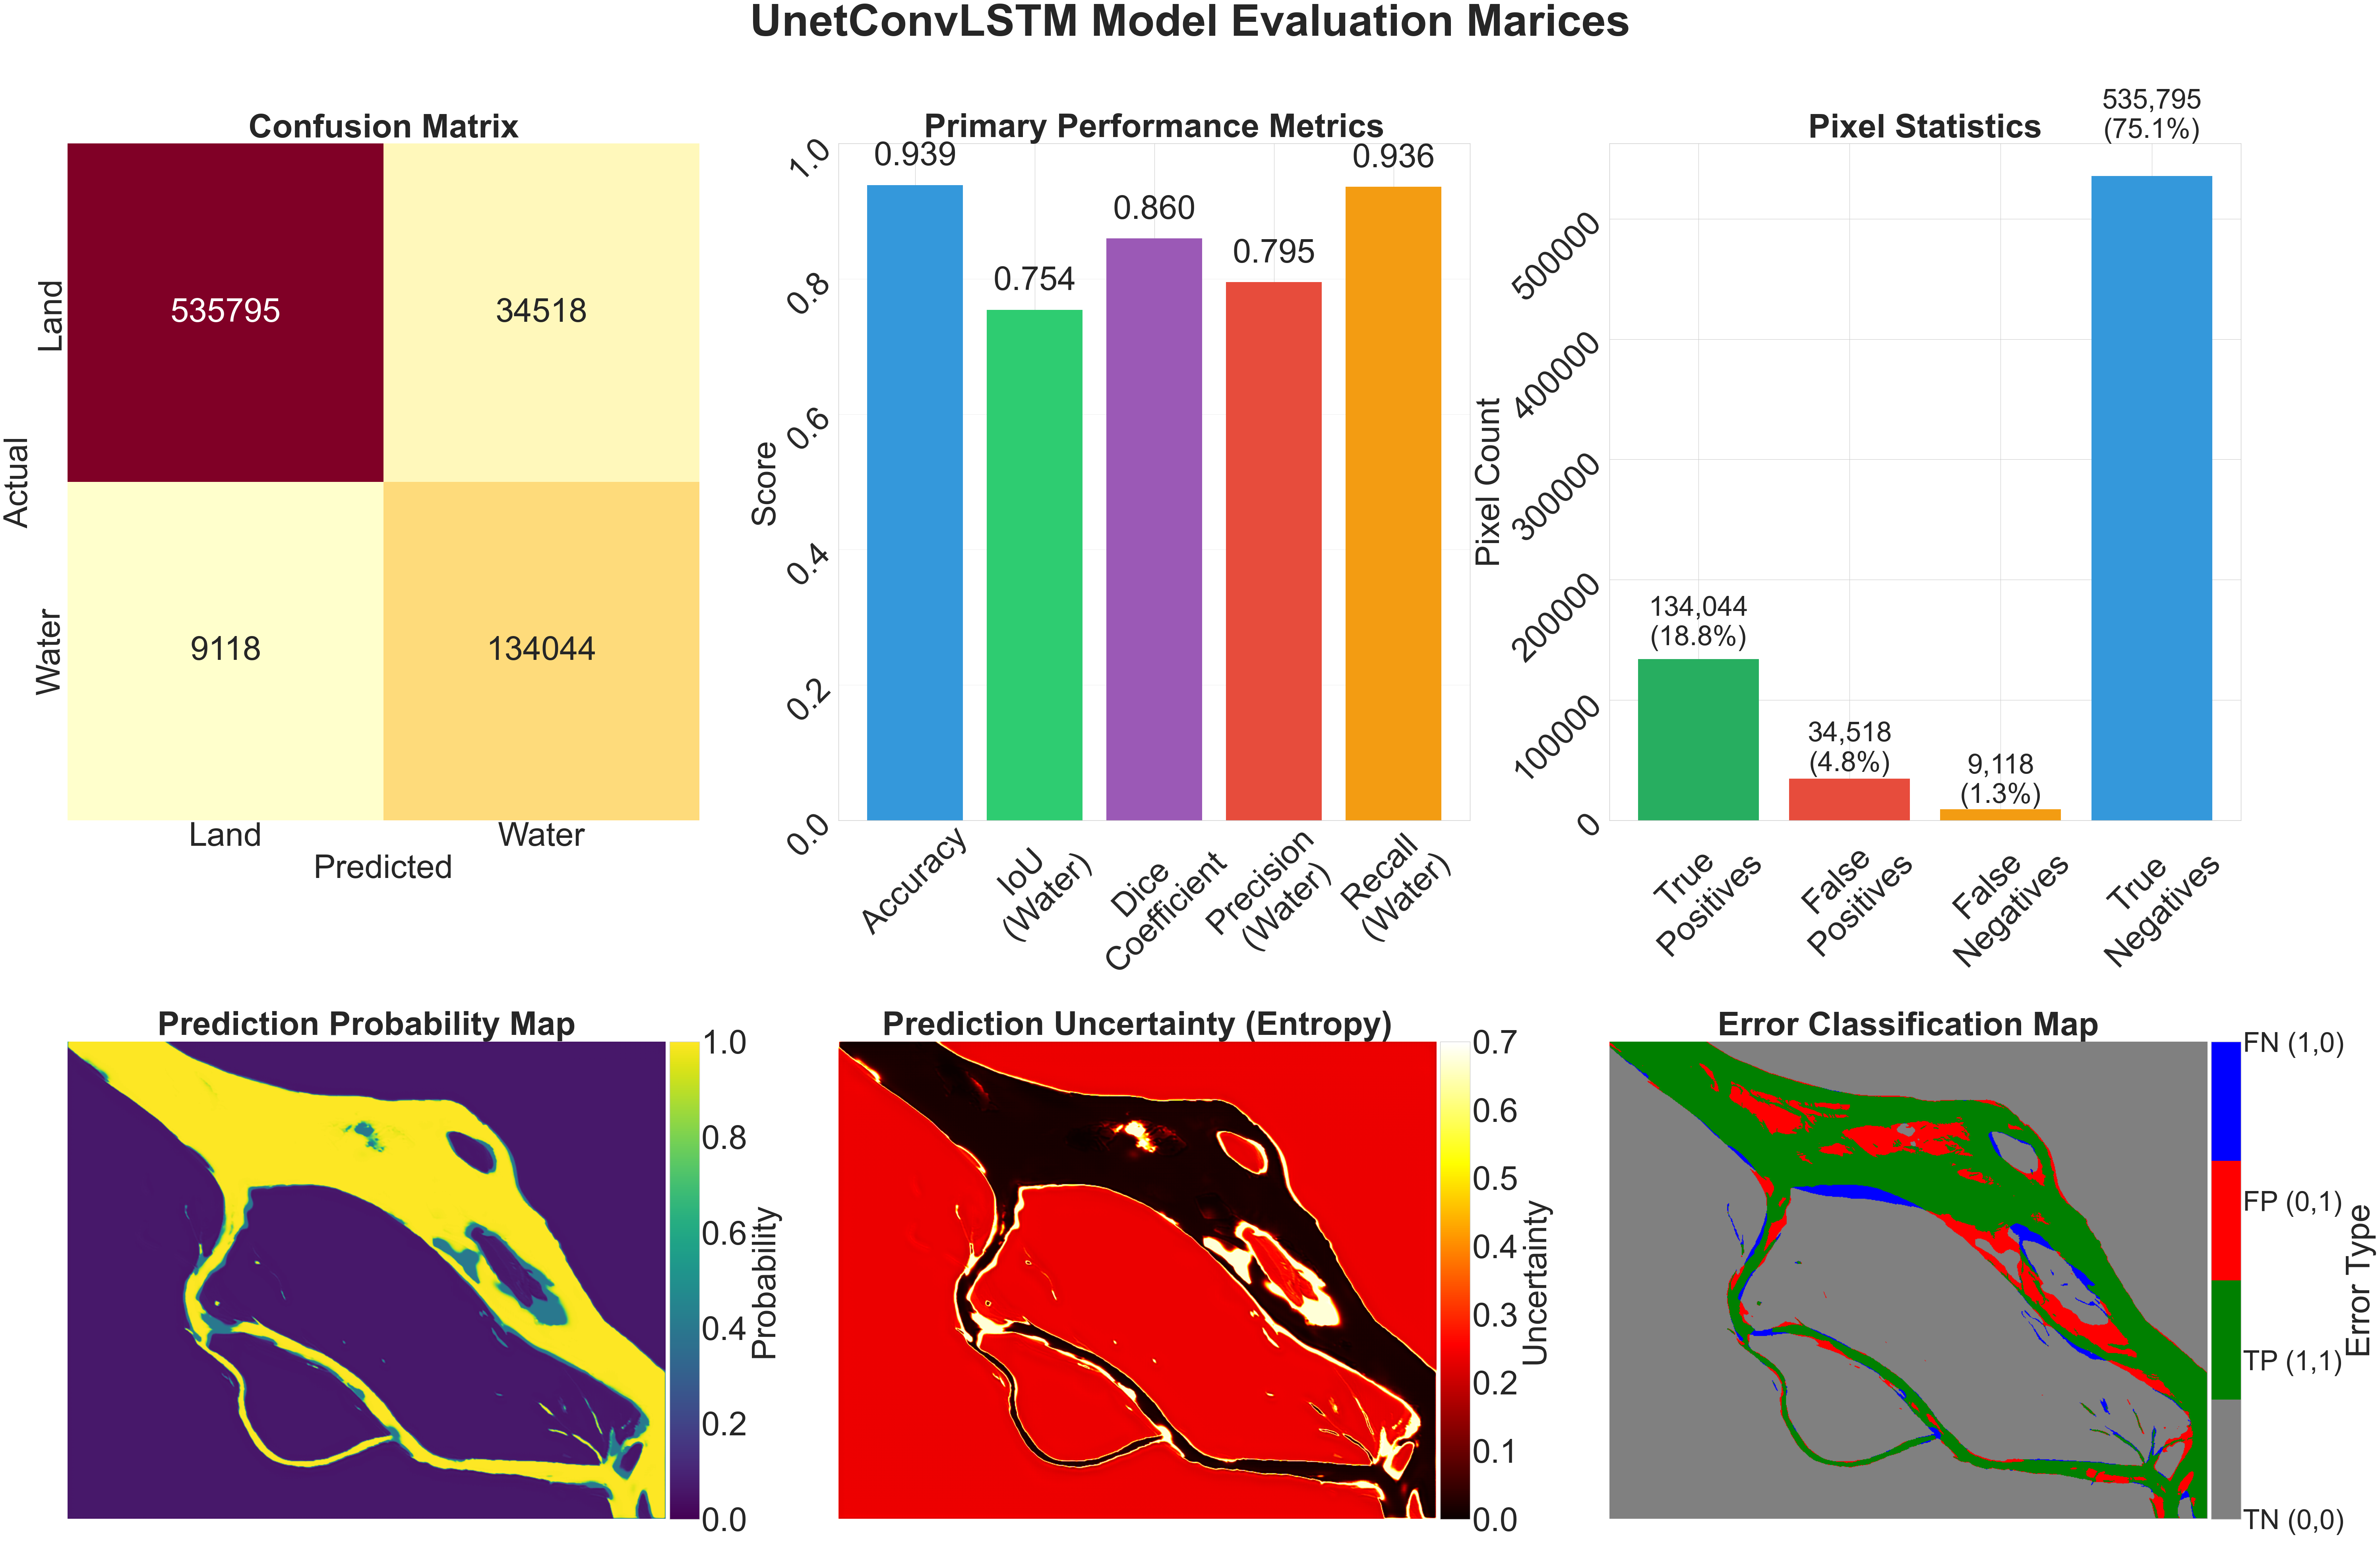

In [14]:
def Matricesplot(y_test, y_pred, model=None, x_test=None, device='cpu', sample_idx=0, save_path=None):
    """Enhanced visualization with metrics including probability and uncertainty maps"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(y_pred, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Get probability map if model and x_test are provided
    prob_map = None
    if model is not None and x_test is not None:
        with torch.no_grad():
            model.eval()
            if isinstance(x_test, np.ndarray):
                x_test = torch.from_numpy(x_test)
            x_test = x_test.to(device)
            predictions = model(x_test)
            
            if predictions.dim() > 2:
                prob_map = predictions[sample_idx, 0].cpu().numpy() if predictions.shape[1] == 1 else predictions[sample_idx].cpu().numpy()
            else:
                prob_map = predictions.cpu().numpy()
    
    # Create figure with 3x2 grid (6 plots total)
    fig = plt.figure(figsize=(60, 40))
    
    # 1. Confusion Matrix Heatmap
    ax1 = plt.subplot(2, 3, 1)
    heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                          annot_kws={"size": 60},
                          xticklabels=['Land', 'Water'], 
                          yticklabels=['Land', 'Water'],
                          ax=ax1,
                          cbar=False)
    ax1.set_title('Confusion Matrix', fontsize=60, fontweight='bold')
    ax1.set_xlabel('Predicted', fontsize=60)
    ax1.set_ylabel('Actual', fontsize=60)
    ax1.tick_params(axis='both', labelsize=60)
    
    # 2. Primary Metrics
    ax2 = plt.subplot(2, 3, 2)
    primary_metrics = ['Accuracy', 'IoU\n(Water)', 'Dice\nCoefficient', 'Precision\n(Water)', 'Recall\n(Water)']
    primary_values = [
        metrics['accuracy'],
        metrics['iou_water'],
        metrics.get('dice_water', metrics.get('f1_water', 0)),
        metrics['precision_water'],
        metrics['recall_water']
    ]
    
    colors1 = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']
    bars1 = ax2.bar(primary_metrics, primary_values, color=colors1)
    ax2.set_ylim([0, 1])
    ax2.set_title('Primary Performance Metrics', fontsize=60, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=60)
    ax2.tick_params(axis='both', labelsize=60, rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars1, primary_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=60)
    
    # 3. Pixel Statistics
    ax3 = plt.subplot(2, 3, 3)
    
    # Calculate pixel statistics
    total_pixels = cm.sum()
    tp, fp, fn, tn = cm[1, 1], cm[0, 1], cm[1, 0], cm[0, 0]
    
    stats_labels = ['True\nPositives', 'False\nPositives', 'False\nNegatives', 'True\nNegatives']
    stats_values = [tp, fp, fn, tn]
    stats_percentages = [tp/total_pixels*100, fp/total_pixels*100, 
                         fn/total_pixels*100, tn/total_pixels*100]
    
    colors3 = ['#27ae60', '#e74c3c', '#f39c12', '#3498db']
    bars3 = ax3.bar(stats_labels, stats_values, color=colors3)
    ax3.set_title('Pixel Statistics', fontsize=60, fontweight='bold')
    ax3.set_ylabel('Pixel Count', fontsize=60)
    ax3.tick_params(axis='both', labelsize=60, rotation=45)
    
    # Add both count and percentage
    for bar, val, pct in zip(bars3, stats_values, stats_percentages):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=50)
    
    # 4. Probability Map (if available)
    ax4 = plt.subplot(2, 3, 4)
    if prob_map is not None:
        im1 = ax4.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax4.set_title('Prediction Probability Map', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1)
        cbar1.ax.tick_params(labelsize=60)
        cbar1.set_label('Probability', fontsize=60)
    else:
        # If no probability map, show actual mask
        if y_test.dim() > 2:
            actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
        else:
            actual_mask = y_test.cpu().numpy()
        
        im1 = ax4.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
        ax4.set_title('Actual Water Mask', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1, ticks=[0, 1])
        cbar1.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar1.set_label('Class', fontsize=60)
    
    # 5. Uncertainty Map (if probability map is available)
    ax5 = plt.subplot(2, 3, 5)
    if prob_map is not None:
        # Calculate entropy as uncertainty measure
        prob_map_clipped = np.clip(prob_map, 1e-10, 1 - 1e-10)  # Avoid log(0)
        uncertainty = -prob_map_clipped * np.log(prob_map_clipped) - (1 - prob_map_clipped) * np.log(1 - prob_map_clipped)
        
        im2 = ax5.imshow(uncertainty, cmap='hot', vmin=0, vmax=0.7)
        ax5.set_title('Prediction Uncertainty (Entropy)', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2)
        cbar2.ax.tick_params(labelsize=60)
        cbar2.set_label('Uncertainty', fontsize=60)
    else:
        # If no uncertainty map, show predicted mask
        if y_pred.dim() > 2:
            pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
        else:
            pred_mask = y_pred.cpu().numpy()
        
        im2 = ax5.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
        ax5.set_title('Predicted Water Mask', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2, ticks=[0, 1])
        cbar2.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar2.set_label('Class', fontsize=60)
    
    # 6. Error Classification Map
    ax6 = plt.subplot(2, 3, 6)
    
    # Get actual and predicted masks
    if y_test.dim() > 2:
        actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
    else:
        actual_mask = y_test.cpu().numpy()
    
    if y_pred.dim() > 2:
        pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
    else:
        pred_mask = y_pred.cpu().numpy()
    
    # Create error map
    pred_mask_bin = (pred_mask > 0.5).astype(np.int32)
    error_map = np.zeros_like(actual_mask, dtype=np.int32)
    error_map[(actual_mask == 0) & (pred_mask_bin == 0)] = 0  # TN
    error_map[(actual_mask == 1) & (pred_mask_bin == 1)] = 1  # TP
    error_map[(actual_mask == 0) & (pred_mask_bin == 1)] = 2  # FP
    error_map[(actual_mask == 1) & (pred_mask_bin == 0)] = 3  # FN
    
    cmap_error = ListedColormap(['gray', 'green', 'red', 'blue'])
    im3 = ax6.imshow(error_map, cmap=cmap_error, vmin=0, vmax=3)
    ax6.set_title('Error Classification Map', fontsize=60, fontweight='bold')
    ax6.axis('off')
    divider3 = make_axes_locatable(ax6)
    cax3 = divider3.append_axes("right", size="5%", pad=0.1)
    cbar3 = plt.colorbar(im3, cax=cax3, ticks=[0, 1, 2, 3])
    cbar3.ax.set_yticklabels(['TN (0,0)', 'TP (1,1)', 'FP (0,1)', 'FN (1,0)'], fontsize=50)
    cbar3.set_label('Error Type', fontsize=60)
    
    plt.suptitle('UnetConvLSTM Model Evaluation Marices', fontsize=80, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # if save_path:
    #     plt.savefig(save_path, dpi=100, bbox_inches='tight')
    #     print(f"Metrics visualization saved to {save_path}")
    
    plt.show()
    
Matricesplot(y_test, y_pred, model=model, x_test=x_test, device=device)